In [5]:
# alex local filepath - yyou need the path to the h5 files in new_data_sync ( or similar name) on the cluster

combined_filepath = r"c:\Users\Lindsay\Documents\alexander\Deer_project\data\signal_from_cluster\R1_D4_Combined.h5"


In [4]:

import pandas as pd



In [6]:
deer_data=pd.read_hdf(combined_filepath)

In [7]:
deer_data.head()

,TagID,X_head,Y_head,Z_head,location-lat,location-lon,DateTime_Global,NZ_DateTime,X_ear,Y_ear,Z_ear
0,AT4 S4Pink 12-13.11_S1,1.9181,-2.3381,5.5481,NaN,NaN,2018-11-11 22:32:20.960,2018-11-12 11:32:20.960,4.468800,-4.703100,-4.171900
1,AT4 S4Pink 12-13.11_S1,-0.4219,-2.9531,4.4531,NaN,NaN,2018-11-11 22:32:20.980,2018-11-12 11:32:20.980,0.309505,-6.302316,1.938201
2,AT4 S4Pink 12-13.11_S1,-2.4531,-3.2500,2.6719,NaN,NaN,2018-11-11 22:32:21.000,2018-11-12 11:32:21.000,-0.844790,-4.678309,4.939194
3,AT4 S4Pink 12-13.11_S1,-2.5450,-3.3725,1.3091,NaN,NaN,2018-11-11 22:32:21.020,2018-11-12 11:32:21.020,-0.765665,-4.018587,6.439003
4,AT4 S4Pink 12-13.11_S1,-2.6069,-3.0300,-0.9537,NaN,NaN,2018-11-11 22:32:21.040,2018-11-12 11:32:21.040,1.381236,-6.008635,6.490636


In [8]:

import math
import numpy as np
def load_and_clean_data(filepath,ear=False):
    if not os.path.exists(filepath):
        print(f"Error: Data file {filepath} does not exist.")
        return pd.DataFrame([])
    if ear==False:
        columns_to_keep=['TagID', 'Date', 'Time', 'X', 'Y', 'Z', 'location-lat','location-lon']
    else:
        columns_to_keep=['TagID', 'Date', 'Time', 'X', 'Y', 'Z']
    data=pd.read_csv(filepath,usecols=columns_to_keep)
    data['DateTime_Global'] = pd.to_datetime(data['Date'] + ' ' + data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
    data['NZ_DateTime'] = data['DateTime_Global'] + pd.Timedelta(hours=13)
    data.drop(['Date', 'Time'], axis=1, inplace=True)
    return data

def calculate_tortuosity_and_speed(lat,lon,fps=0.5):
    tortuosity_values = []
    absolute_speeds = [] 
    for i in range(len(lat) - 2):
        # Vector norm from the Point 0 to Point 1
        vn1 = lat_lon_vec_to_meter_vec(lat[i],lon[i],lat[i+1],lon[i+1])
        
        # Vector norm from the Point 1 to Point 2
        vn2 = lat_lon_vec_to_meter_vec(lat[i+1],lon[i+1],lat[i+2],lon[i+2])
        
        # Vector norm from the Point 0 to Point 2
        vn = lat_lon_vec_to_meter_vec(lat[i],lon[i],lat[i+2],lon[i+2])
        
        absolute_speeds.append(vn1/fps)
        
        # Handle division by zero
        if vn2 + vn1 == 0:
            tortuosity_values.append(0)  # or any other default value
        else:
            tortuosity_values.append(vn / (vn2 + vn1))
    
    #get last absolute speed        
    i += 1
    # Vector norm from the Poitn 0 to Point 1
    vn1 = lat_lon_vec_to_meter_vec(lat[i],lon[i],lat[i+1],lon[i+1])
    absolute_speeds.append(vn1/fps)
        
    tortuosity_values.insert(0, tortuosity_values[0]) # append 2 zeros for the end 
    tortuosity_values.append(tortuosity_values[-1])
    absolute_speeds.insert(0, absolute_speeds[0]) 
    return {"tortuosity":tortuosity_values,"speed": absolute_speeds}

def lat_lon_vec_to_meter_vec(lat1, lon1, lat2, lon2):  # generally used geo measurement function
    R = 6378.137 # Radius of earth in KM
    dLat = lat2 * np.pi / 180 - lat1 * np.pi / 180
    dLon = lon2 * np.pi / 180 - lon1 * np.pi / 180
    
    a = np.sin(dLat/2) * np.sin(dLat/2) + np.cos(lat1 * np.pi / 180) * np.cos(lat2 * np.pi / 180) * np.sin(dLon/2) * np.sin(dLon/2)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    d = R * c
    return d * 1000  #meters

In [9]:
pos_data = deer_data.loc[:,['location-lat','location-lon']].copy()
pos_data = pos_data.dropna()
pos_data.head()
result_dict = calculate_tortuosity_and_speed(pos_data['location-lat'].to_numpy(),
                                             pos_data['location-lon'].to_numpy())
print(result_dict)

pos_data['tortuosity']= result_dict['tortuosity']
pos_data["absolute_speed"]= result_dict["speed"]
pos_data.head()

{'tortuosity': [0.9556564248137828, 0.9556564248137828, 0.0, 0.40404947920068096, 0.7188303974135808, 0.9802060011075452, 0.8332497320988561, 0.40404946424703747, 0.3462471257943412, 0.44708291078067436, 0.9605001364236799, 0.9605000762385074, 0.8763869537660285, 0.7429545602919225, 0.8667724460159759, 0.8310387448911231, 0.712121339985385, 1.0, 0.9194413589678504, 0.9194414249187678, 0.7121212501028613, 0.0, 0.6450789396838932, 0.16762069720263909, 0.8785347236807126, 0.6422340300095702, 0.5493620085579447, 0.2908538834241567, 0.9007317820407157, 0.5449145466737697, 0.9963174356486766, 0.3434412960750874, 0.8607037365134328, 0.9999999999999954, 0.9999999999999983, 1.0, 1.0, 0.9668964374907398, 1.0, 1.0, 0.0, 0.9477545839578008, 1.0, 0.9517018581243356, 0.6247606993050986, 0.31702230069944803, 0.5363359688586283, 0.5493620030923926, 0.9556564170594055, 0.8684668359879564, 0.681191357237607, 1.0, 1.0, 0.9999999999999908, 0.4799239780504339, 0.9999999999999911, 0.9605000329354683, 0.9829

,location-lat,location-lon,tortuosity,absolute_speed
52,-38.11025,175.49809,0.955656,5.665876
152,-38.11027,175.49807,0.955656,5.665876
252,-38.11028,175.49807,0.000000,2.226390
352,-38.11027,175.49807,0.404049,2.226390
452,-38.11029,175.49808,0.718830,4.784973


In [11]:
pos_data.iloc[1:20,:]
# add columns abs speed and tort
# tge na dd to oritginal
# rename absolute sopeedto abs_speed_mps

,location-lat,location-lon,tortuosity,absolute_speed
152,-38.11027,175.49807,0.955656,5.665876
252,-38.11028,175.49807,0.000000,2.226390
352,-38.11027,175.49807,0.404049,2.226390
452,-38.11029,175.49808,0.718830,4.784973
552,-38.11030,175.49805,0.980206,5.707480
652,-38.11030,175.49801,0.833250,7.007109
752,-38.11028,175.49800,0.404049,4.784973
852,-38.11029,175.49800,0.346247,2.226390
952,-38.11028,175.49799,0.447083,2.832938
1052,-38.11028,175.49801,0.960500,3.503555


In [8]:
original_deer_data=deer_data.loc[:,['location-lat','location-lon']].copy()
original_deer_data['tortuosity'] = pd.NA
original_deer_data["absolute_speed"] = pd.NA
original_deer_data.update(pos_data)
print(original_deer_data.iloc[140:160,:])

     location-lat  location-lon tortuosity absolute_speed
140           NaN           NaN       <NA>           <NA>
141           NaN           NaN       <NA>           <NA>
142           NaN           NaN       <NA>           <NA>
143           NaN           NaN       <NA>           <NA>
144           NaN           NaN       <NA>           <NA>
145           NaN           NaN       <NA>           <NA>
146           NaN           NaN       <NA>           <NA>
147           NaN           NaN       <NA>           <NA>
148           NaN           NaN       <NA>           <NA>
149           NaN           NaN       <NA>           <NA>
150           NaN           NaN       <NA>           <NA>
151           NaN           NaN       <NA>           <NA>
152     -38.11027     175.49807   0.955656       5.665876
153           NaN           NaN       <NA>           <NA>
154           NaN           NaN       <NA>           <NA>
155           NaN           NaN       <NA>           <NA>
156           

In [9]:
deer_data_interpolated=original_deer_data.copy()
deer_data_interpolated['location-lat'].interpolate(method='linear', inplace=True) # linearly interpolate all Nas between obs of location
deer_data_interpolated['location-lon'].interpolate(method='linear', inplace=True)
deer_data_interpolated['tortuosity'].interpolate(method='linear', inplace=True)
deer_data_interpolated['absolute_speed'].interpolate(method='linear', inplace=True)


deer_data_interpolated['location-lat'].bfill(inplace=True) # bfill and FFill any extra Nas
deer_data_interpolated['location-lon'].bfill(inplace=True)
deer_data_interpolated['location-lat'].ffill(inplace=True)
deer_data_interpolated['location-lon'].ffill(inplace=True)
deer_data_interpolated['tortuosity'].ffill(inplace=True)
deer_data_interpolated['tortuosity'].bfill(inplace=True)
deer_data_interpolated['absolute_speed'].ffill(inplace=True)
deer_data_interpolated['absolute_speed'].bfill(inplace=True)

C:\Users\Lindsay\AppData\Local\Temp\ipykernel_12616\1158023399.py:4: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  deer_data_interpolated['tortuosity'].interpolate(method='linear', inplace=True)
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_12616\1158023399.py:5: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  deer_data_interpolated['absolute_speed'].interpolate(method='linear', inplace=True)


In [10]:
deer_data_interpolated.iloc[140:160,:]

,location-lat,location-lon,tortuosity,absolute_speed
140,-38.110268,175.498072,0.955656,5.665876
141,-38.110268,175.498072,0.955656,5.665876
142,-38.110268,175.498072,0.955656,5.665876
143,-38.110268,175.498072,0.955656,5.665876
144,-38.110268,175.498072,0.955656,5.665876
145,-38.110269,175.498071,0.955656,5.665876
146,-38.110269,175.498071,0.955656,5.665876
147,-38.110269,175.498071,0.955656,5.665876
148,-38.110269,175.498071,0.955656,5.665876
149,-38.110269,175.498071,0.955656,5.665876


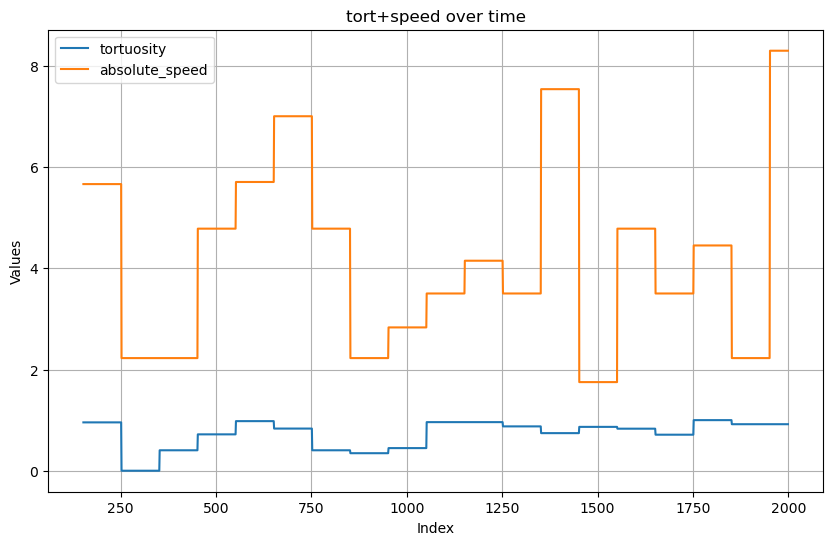

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = deer_data_interpolated.iloc[152:2000]

# Create a line plot for all four columns
data_subset.plot(y=[ 'tortuosity', 'absolute_speed'], figsize=(10, 6))

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

# Display the 

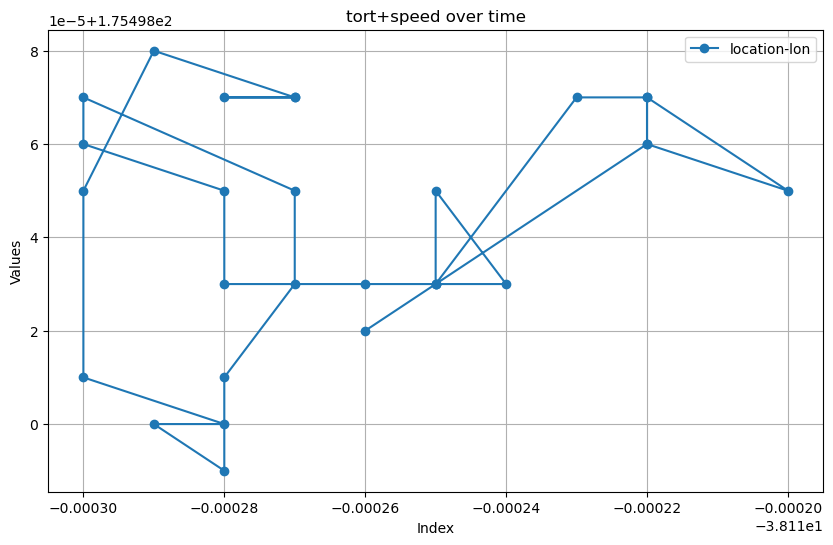

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = pos_data.iloc[1:30]
#data_subset=deer_data_interpolated.iloc[152:2000]
# Create a line plot for all four columns
data_subset.plot( 'location-lat', 'location-lon', figsize=(10, 6), marker = "o")

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (replace 'data.csv' with your file path)
data = pos_data.iloc[1:600].copy()
# Calculate moving average for latitude and longitude with window size of 30
window_size = 5
data['avg_lat'] = data['location-lat'].rolling(window=window_size).mean()
data['avg_lon'] = data['location-lon'].rolling(window=window_size).mean()


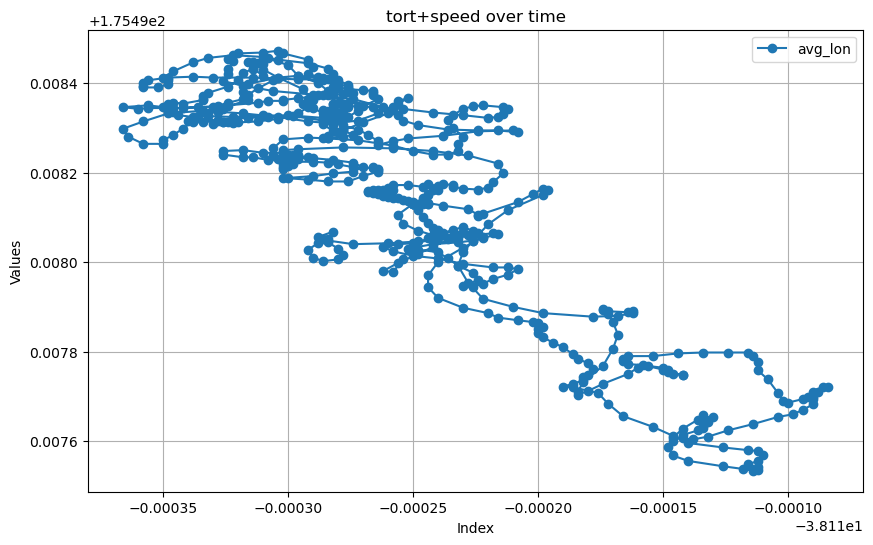

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select the first 10000 rows
data_subset = data
#data_subset=deer_data_interpolated.iloc[152:2000]
# Create a line plot for all four columns
data_subset.plot( 'avg_lat', 'avg_lon', figsize=(10, 6), marker = "o")

# Customize the plot (optional)
plt.title('tort+speed over time')  # Change title to 'Change' in Japanese
plt.xlabel('Index')
plt.ylabel('Values')
plt.legend()
plt.grid(True)

C:\Users\Lindsay\AppData\Local\Temp\ipykernel_25492\4125127242.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=data['avg_lon'], y=data['avg_lat'], cmap='viridis', shade=True, cbar=True)
c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


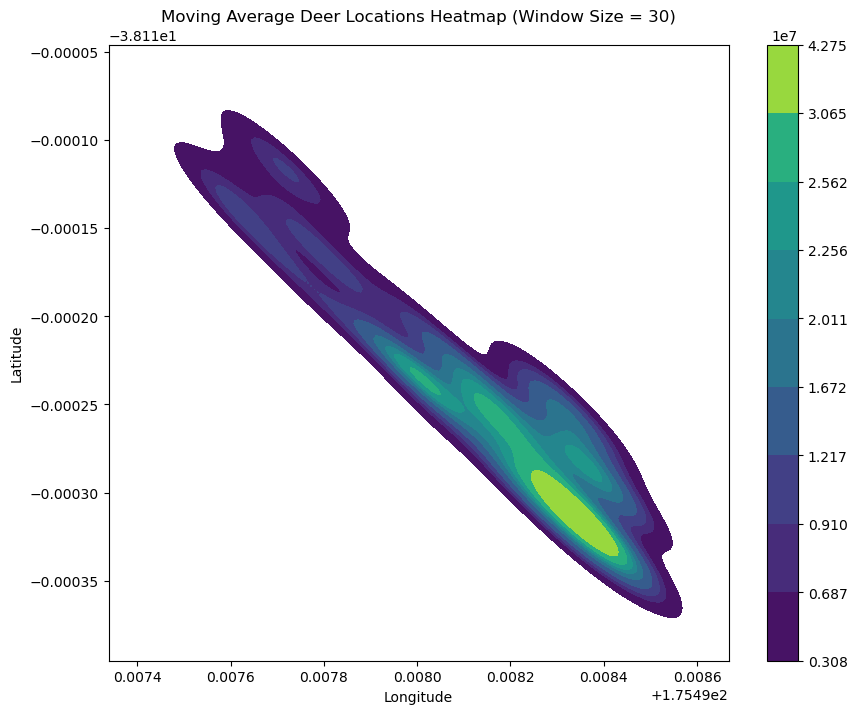

In [14]:

# Create heatmap using Seaborn with moving average
plt.figure(figsize=(10, 8))
sns.kdeplot(x=data['avg_lon'], y=data['avg_lat'], cmap='viridis', shade=True, cbar=True)
plt.title('Moving Average Deer Locations Heatmap (Window Size = 30)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


# check it worked with plots
then run on all data

In [12]:
# tort_and_speed=calculate_tortuosity_and_speed(deer_data_interpolated['location-lat'], deer_data_interpolated['location-lon'])

# deer_data_interpolated['tortuosity']= tort_and_speed['tortuosity']
# deer_data_interpolated["absolute_speed"]= tort_and_speed["speed"]

KeyboardInterrupt: 

# Heatmap of deer position

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data (replace 'data.csv' with your file path)
data = pos_data
# Create heatmap using Seaborn
plt.figure(figsize=(10, 8))
sns.kdeplot(x=data['location-lon'], y=data['location-lat'], cmap='viridis', shade=True, cbar=True)
plt.title('Deer Locations Heatmap')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


C:\Users\Lindsay\AppData\Local\Temp\ipykernel_8468\994544155.py:10: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=data['location-lon'], y=data['location-lat'], cmap='viridis', shade=True, cbar=True)
c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
